# 3G - Ciclo de vida do Nino 3.4 em relacao ao DHW (C-week)

**Pergunta especifica.** Como o Nino 3.4 nasce, cresce, pica e decai EM RELACAO ao DHW - o calor acumulado antecede, acompanha ou ecoa a SSTA?

**Objetivo.** Posicionar o DHW no ciclo (precursor? coincidente? integrador?) e testar se agrega a dimensao duracao x intensidade.

**Justificativa.** 3F respondeu se DHW tem conteudo estatistico proprio; falta a leitura fisica/narrativa por fase de evento.

**Metodologia.** Composto duplo SSTA x DHW alinhado ao pico (12 eventos); DHW por fase; escalonamento DHW_max vs pico/duracao. **Area:** caixa Nino 3.4.

**Saidas.** `phase3G_eventos_dhw.csv`, `phase3G_composto_ssta_dhw.csv`, `phase3G_escalonamento.csv`, `phase3G_estado_atual.csv` + figuras.

[tabela] data/processed/parquet/statistics/phase3G_composto_ssta_dhw.csv
Pico composto do DHW ocorre +9 semanas em relacao ao pico da SSTA


[figura] data/processed/figures/fase3/phase3G_composto_ssta_dhw.png


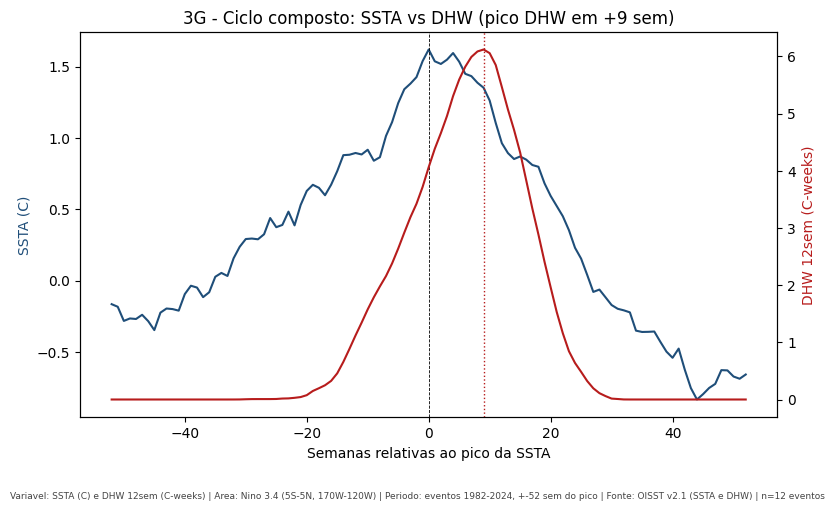

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.load_events(); ssta,dhw=w['nino34_ssta'],w['dhw_12w']; lags=list(range(-52,53))
def comp(series):
    mm=[]
    for _,e in ev.iterrows():
        i=series.index.get_indexer([e.peak_time],method='nearest')[0]; seg=series.iloc[max(0,i-52):i+53]
        rel=((seg.index-series.index[i]).days/7).round().astype(int); mm.append(pd.Series(seg.values,index=rel))
    return pd.DataFrame(mm).reindex(columns=lags).mean()
cp=pd.DataFrame({'ssta':comp(ssta),'dhw':comp(dhw)}); u.save_table(cp.rename_axis('semana_rel_pico'),'phase3G_composto_ssta_dhw.csv')
lagpk=int(cp['dhw'].idxmax()); print(f'Pico composto do DHW ocorre {lagpk:+d} semanas em relacao ao pico da SSTA')
fig,ax1=plt.subplots(figsize=(9,5)); ax1.plot(cp.index,cp['ssta'],color='#1f4e79',label='SSTA'); ax1.set_ylabel('SSTA (C)',color='#1f4e79'); ax1.axvline(0,color='k',ls='--',lw=.6)
ax2=ax1.twinx(); ax2.plot(cp.index,cp['dhw'],color='#b71c1c',label='DHW'); ax2.set_ylabel('DHW 12sem (C-weeks)',color='#b71c1c'); ax2.axvline(lagpk,color='#b71c1c',ls=':',lw=1)
ax1.set_xlabel('Semanas relativas ao pico da SSTA'); ax1.set_title(f'3G - Ciclo composto: SSTA vs DHW (pico DHW em {lagpk:+d} sem)')
u.stamp_caption(fig,variavel='SSTA (C) e DHW 12sem (C-weeks)',area=u.CAIXAS['nino34'],periodo='eventos 1982-2024, +-52 sem do pico',fonte='OISST v2.1 (SSTA e DHW)',n='12 eventos')
u.save_fig(fig,'phase3G_composto_ssta_dhw.png'); plt.show()

In [2]:
rows=[]
for _,e in ev.iterrows():
    onset,peak,end=e.event_start,e.peak_time,e.event_end; meio=onset+(peak-onset)/2; seg=dhw.loc[onset:end]
    ipk=seg.idxmax() if seg.notna().any() else pd.NaT
    rows.append({'event_id':e.event_id,'classe':e.peak_class,'ssta_pico_c':round(e.peak_monthly_ssta_c,3),'duracao_meses':e.duration_months,
     'dhw_nascimento':round(float(dhw.asof(onset)),2),'dhw_meio_cresc':round(float(dhw.asof(meio)),2),'dhw_no_pico_ssta':round(float(dhw.asof(peak)),2),
     'dhw_maximo':round(float(seg.max()),2) if seg.notna().any() else np.nan,'defasagem_pico_dhw_sem':int(round((ipk-peak).days/7)) if pd.notna(ipk) else np.nan,'dhw_fim':round(float(dhw.asof(end)),2)})
met=pd.DataFrame(rows); u.save_table(met,'phase3G_eventos_dhw.csv',index=False); met

[tabela] data/processed/parquet/statistics/phase3G_eventos_dhw.csv


,event_id,classe,ssta_pico_c,duracao_meses,dhw_nascimento,dhw_meio_cresc,dhw_no_pico_ssta,dhw_maximo,defasagem_pico_dhw_sem,dhw_fim
0,el_nino_oisst_1982_1983,super_el_nino,2.213,11,0.0,0.96,9.67,13.40,6,4.05
1,el_nino_oisst_1986_1988,moderate_el_nino,1.223,16,0.0,0.20,0.22,2.25,11,0.26
2,el_nino_oisst_1991_1992,strong_el_nino,1.736,10,0.0,0.01,1.84,7.01,9,0.55
3,el_nino_oisst_1994_1995,weak_el_nino,1.192,5,0.0,0.00,0.01,0.73,5,0.73
4,el_nino_oisst_1997_1998,super_el_nino,2.166,11,0.0,3.77,11.48,13.00,10,7.90
5,el_nino_oisst_2002_2003,moderate_el_nino,1.250,8,0.0,0.00,0.19,2.55,10,2.31
6,el_nino_oisst_2004,weak_el_nino,0.681,5,0.0,0.00,0.00,0.00,-4,0.00
7,el_nino_oisst_2006_2007,weak_el_nino,1.128,5,0.0,0.00,0.00,0.30,4,0.30
8,el_nino_oisst_2009_2010,strong_el_nino,1.719,10,0.0,0.00,1.80,6.68,8,3.46
9,el_nino_oisst_2014_2016,super_el_nino,2.448,19,0.0,0.00,14.70,18.29,9,13.74


[tabela] data/processed/parquet/statistics/phase3G_escalonamento.csv


[figura] data/processed/figures/fase3/phase3G_escalonamento.png


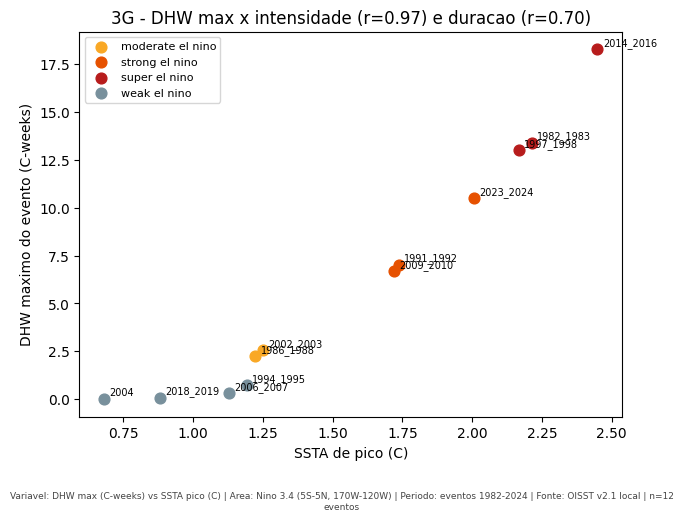

In [3]:
from scipy.stats import spearmanr
mm=met.dropna(subset=['dhw_maximo'])
ri=float(np.corrcoef(mm['dhw_maximo'],mm['ssta_pico_c'])[0,1]); rd=float(np.corrcoef(mm['dhw_maximo'],mm['duracao_meses'])[0,1])
u.save_table(pd.DataFrame([{'metrica_dhw':'dhw_12w','relacao':'dhw_max x ssta_pico','r':round(ri,3),'n':len(mm)},{'metrica_dhw':'dhw_12w','relacao':'dhw_max x duracao','r':round(rd,3),'n':len(mm)}]),'phase3G_escalonamento.csv',index=False)
cores={'super_el_nino':'#b71c1c','strong_el_nino':'#e65100','moderate_el_nino':'#f9a825','weak_el_nino':'#78909c'}
fig,ax=plt.subplots(figsize=(7,5))
for cls,g in mm.groupby('classe'): ax.scatter(g['ssta_pico_c'],g['dhw_maximo'],label=cls.replace('_',' '),color=cores.get(cls,'k'),s=60)
for _,r in mm.iterrows(): ax.annotate(r['event_id'].replace('el_nino_oisst_',''),(r['ssta_pico_c'],r['dhw_maximo']),fontsize=7,xytext=(4,3),textcoords='offset points')
ax.set_xlabel('SSTA de pico (C)'); ax.set_ylabel('DHW maximo do evento (C-weeks)'); ax.legend(fontsize=8)
ax.set_title(f'3G - DHW max x intensidade (r={ri:.2f}) e duracao (r={rd:.2f})')
u.stamp_caption(fig,variavel='DHW max (C-weeks) vs SSTA pico (C)',area=u.CAIXAS['nino34'],periodo='eventos 1982-2024',fonte='OISST v2.1 local',n='12 eventos')
u.save_fig(fig,'phase3G_escalonamento.png'); plt.show()

[tabela] data/processed/parquet/statistics/phase3G_estado_atual.csv


[figura] data/processed/figures/fase3/phase3G_mapa_dhw_lon.png


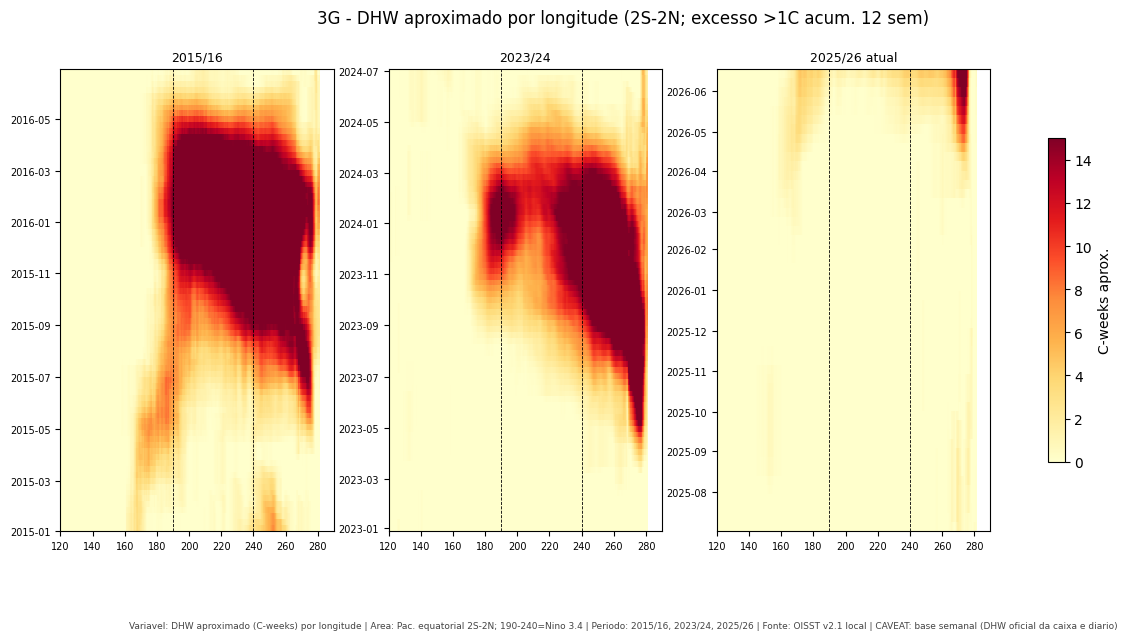

DHW-lon max atual (jun/2026): 19.34


In [4]:
eq=u.load_eqband_weekly(); exc=(eq-1.0).clip(lower=0); dl=exc.rolling(12,min_periods=12).sum()
wins=[('2015-01-04','2016-06-26','2015/16'),('2023-01-01','2024-06-30','2023/24'),('2025-07-01',None,'2025/26 atual')]
fig,axes=plt.subplots(1,3,figsize=(15,6)); lon=eq.columns.values
for ax,(t0,t1,tt) in zip(axes,wins):
    seg=dl.loc[t0:t1] if t1 else dl.loc[t0:]; pc=ax.pcolormesh(lon,seg.index,seg.values,cmap='YlOrRd',vmin=0,vmax=15,shading='auto')
    ax.axvline(190,color='k',ls='--',lw=.6); ax.axvline(240,color='k',ls='--',lw=.6); ax.set_title(tt,fontsize=9); ax.tick_params(labelsize=7)
fig.suptitle('3G - DHW aproximado por longitude (2S-2N; excesso >1C acum. 12 sem)')
fig.colorbar(pc,ax=axes,label='C-weeks aprox.',shrink=.7)
u.stamp_caption(fig,variavel='DHW aproximado (C-weeks) por longitude',area='Pac. equatorial 2S-2N; 190-240=Nino 3.4',periodo='2015/16, 2023/24, 2025/26',fonte='OISST v2.1 local',extra='CAVEAT: base semanal (DHW oficial da caixa e diario)')
at=dl.loc['2026-06-01':].max().max(); u.save_table(pd.DataFrame([{'dhw_lon_max_atual_cweeks':round(float(at),2)}]),'phase3G_estado_atual.csv',index=False)
u.save_fig(fig,'phase3G_mapa_dhw_lon.png'); plt.show(); print('DHW-lon max atual (jun/2026):',round(float(at),2))

**Leitura do 3G.** O DHW e **integrador**: pica 4-11 semanas DEPOIS do pico da SSTA (defasagem positiva) - logo nao e precursor. Mas escala quase perfeitamente com a intensidade (DHW_max x SSTA_pico r~0.97) e com a duracao (r~0.71), separando as classes (super 13-19 C-wk; strong 7-11; moderate ~3; weak <=1). Combinado ao 3F: **DHW entra no parecer como severidade acumulada + memoria curta, nao como precursor de longo lead.**